## Spotify Decade Prediction System

This study predicts the decade in recorded release metadata using the [600k-track Kaggle dataset](https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks), version 1. Audio descriptors follow [Spotify’s definitions](https://developer.spotify.com/documentation/web-api/reference/get-audio-features). Album/reissue dates need not identify the original recording era; this is a limitation of the target.


### 2. Data Loading and Initial Inspection

First, we will import the necessary libraries and load the raw dataset.

In [1]:
import sys
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

/Users/alejandrotreny/Library/Mobile Documents/com~apple~CloudDocs/Github/Data Science/Data-Science-Ecosystem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [3]:
# Reuse an explicit local CSV, otherwise fetch the fixed public dataset version.
local_csv = Path(os.getenv("SPOTIFY_TRACKS_CSV", "data/tracks.csv")).expanduser()
file_path = local_csv if local_csv.is_file() else Path(kagglehub.dataset_download(
    "yamaerenay/spotify-dataset-19212020-600k-tracks/versions/1", path="tracks.csv"
))
tracks = pd.read_csv(file_path)
if tracks.empty or tracks['id'].isna().any():
    raise ValueError("The source must contain nonmissing track IDs")
print(f"Source rows: {len(tracks):,}; repeated track IDs: {tracks['id'].duplicated().sum():,}")
tracks = tracks.drop_duplicates('id').copy()
print(f"Dataset loaded: {tracks.shape}")


Source rows: 586,672; repeated track IDs: 0
Dataset loaded: (586672, 20)


In [4]:
tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


### 3. Column Descriptions & Feature Selection

To interpret the model's results correctly, we must understand the technical definition and value range of each feature provided by the Spotify API.

#### A. Mood & rhythmic properties (0.0 to 1.0 scale)

These features are normalized probabilities or measurements between 0 and 1.

`danceability`

- Definition: Describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity.
- Range: 0.0 (Least danceable) to 1.0 (Most danceable).

`energy`

- Definition: A perceptual measure of intensity and activity. Energetic tracks feel fast, loud, and noisy. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy.
- Range: 0.0 (Least energetic) to 1.0 (Most energetic).

`valence`

- Definition: A measure describing the musical "positiveness" conveyed by a track. Tracks with high valence sound more positive (e.g., happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g., sad, depressed, angry).
- Range: 0.0 (Negative/Sad) to 1.0 (Positive/Happy).

`acousticness`

- Definition: A confidence measure of whether a track is acoustic, as defined by the source descriptor. 
- Range: 0.0 (Not acoustic) to 1.0 (Acoustic).

`instrumentalness`

- Definition: Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal".
- Range: 0.0 (Not instrumental) to 1.0 (Instrumental). Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0.

`speechiness`

- Definition: Detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value.
- Range: 0.0 (Not speech) to 1.0 (Speech). Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech (e.g. rap music).

#### B. Technical Audio Properties

These features have physical units or specific categorical mappings.

`loudness`

- Definition: The overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track. It is an audio descriptor, not a measure of recording quality or proof of a historical cause.
- Range: Typically -60.0 dB to 0.0 dB.

`tempo`

- Definition: The overall estimated tempo of a track in beats per minute (BPM).
- Range: Typically 50.0 to 250.0 BPM.

`key`

- Definition: The key the track is in. Integers map to pitches using standard Pitch Class notation.
- Range: 0 = C, 1 = C♯/D♭, 2 = D, ..., 11 = B. If no key was detected, the value is -1.

`mode`

- Definition: Indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived.
- Range: 0 (Minor) or 1 (Major).

`duration_ms`

- Definition: The duration of the track in milliseconds.
- Range: Integer values (e.g., 200000 ms is approx 3:20 min).

#### Dropping Irrelevant Columns

To prevent overfitting and data leakage, we must remove identifiers and variables that do not describe the audio itself.

*   `id`, `name`, `id_artists`, `artists`: These are unique identifiers or text strings with high cardinality. They do not generalize trends for a decade prediction model.
*   `popularity`: This is a dynamic metric based on current consumption. A song from the 60s can be popular today. It introduces noise and does not reflect the song's inherent audio characteristics.

*Note: We will keep `release_date` momentarily to extract the 'Decade' target variable, and then we will drop it.*

In [5]:
# Convert release_date to datetime to handle mixed formats (YYYY-MM-DD and YYYY)
tracks['release_date'] = pd.to_datetime(tracks['release_date'], format='mixed', errors='coerce')

# Extract year and calculate decade
tracks['year'] = tracks['release_date'].dt.year
tracks['decade'] = (tracks['year'] // 10) * 10

# Drop columns
cols_to_drop = ['id', 'name', 'id_artists', 'artists', 'popularity', 'explicit', 'release_date', 'year']
tracks_clean = tracks.drop(columns=cols_to_drop)

print("Columns dropped. New shape:", tracks_clean.shape)
tracks_clean.head()

Columns dropped. New shape: (586672, 14)


,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,decade
0,126903,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3,1920
1,98200,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1,1920
2,181640,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5,1920
3,176907,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3,1920
4,163080,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4,1920


### 4. Data Cleaning: Missing Values and Duplicates

We need to ensure the data is clean before visualization.

- Missing Values: We check if any audio features are null.

- Duplicates: We check for identical rows which could bias the model.

In [6]:
print("Missing values before filtering:")
print(tracks_clean.isna().sum())
rows_before = len(tracks_clean)
tracks_clean = tracks_clean.replace([np.inf, -np.inf], np.nan).dropna().copy()
feature_cols = [c for c in tracks_clean if c != 'decade']
conflicting = tracks_clean.groupby(feature_cols, dropna=False)['decade'].transform('nunique') > 1
print(f"Rows with identical audio but conflicting decades: {conflicting.sum():,}")
tracks_clean = tracks_clean.loc[~conflicting].drop_duplicates(feature_cols).copy()
tracks_clean['decade'] = tracks_clean['decade'].astype(int)
print(f"Rows removed for missing values or duplicate/conflicting audio: {rows_before-len(tracks_clean):,}")

# Fixed study eligibility and balancing, established before feature EDA.
tracks_filtered = tracks_clean.loc[
    tracks_clean['duration_ms'].between(60000,600000) & tracks_clean['decade'].between(1940,2020)
].drop(columns=['key','mode']).copy()
# Key and mode are omitted by design; deduplicate again in the actual model space.
model_features = [c for c in tracks_filtered if c != 'decade']
conflicting = tracks_filtered.groupby(model_features, dropna=False)['decade'].transform('nunique') > 1
tracks_filtered = tracks_filtered.loc[~conflicting].drop_duplicates(model_features)
min_count = int(tracks_filtered['decade'].value_counts().min())
balanced_df = tracks_filtered.groupby('decade').sample(n=min_count, random_state=42).reset_index(drop=True)
X = balanced_df.drop(columns='decade')
y = balanced_df['decade']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)
train_pool = X_train.assign(decade=y_train)
assert set(X_train.index).isdisjoint(X_test.index)
assert not pd.MultiIndex.from_frame(X_train).isin(pd.MultiIndex.from_frame(X_test)).any()
assert np.isfinite(X_train.to_numpy()).all() and np.isfinite(X_test.to_numpy()).all()


Missing values before filtering:
duration_ms         0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
decade              0
dtype: int64


Rows with identical audio but conflicting decades: 6,903
Rows removed for missing values or duplicate/conflicting audio: 23,591


### 5. Training-Set Exploration

The plots use only the fixed training partition of the balanced study. The test partition is reserved for evaluation. Equal class sampling defines an artificial uniform-decade benchmark; its accuracy does not estimate performance under Spotify’s catalog distribution.


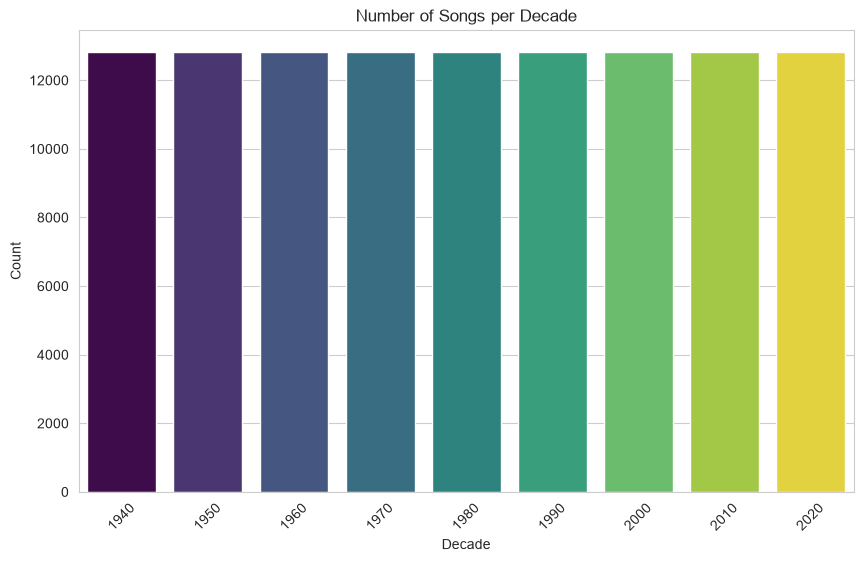

decade
1940    12829
1950    12829
1960    12829
1970    12828
1980    12829
1990    12829
2000    12828
2010    12829
2020    12829
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(x='decade', data=train_pool, hue='decade', palette='viridis', legend=False)
plt.title('Number of Songs per Decade')
plt.ylabel('Count')
plt.xlabel('Decade')
plt.xticks(rotation=45)
plt.show()

print(train_pool['decade'].value_counts().sort_index())

#### 5.2 Feature Distributions (Density Plots)

Now, let's look at the continuous variables (like danceability, tempo, loudness). We use Kernel Density Estimation (KDE) plots, which are like smooth histograms.

What to look for:

- Bimodal distributions: If a curve has two "humps", it suggests there are two distinct groups of songs.

- Skewness: If the data is bunched up to the left or right (e.g., speechiness usually has a huge peak near 0 because most songs aren't spoken word).

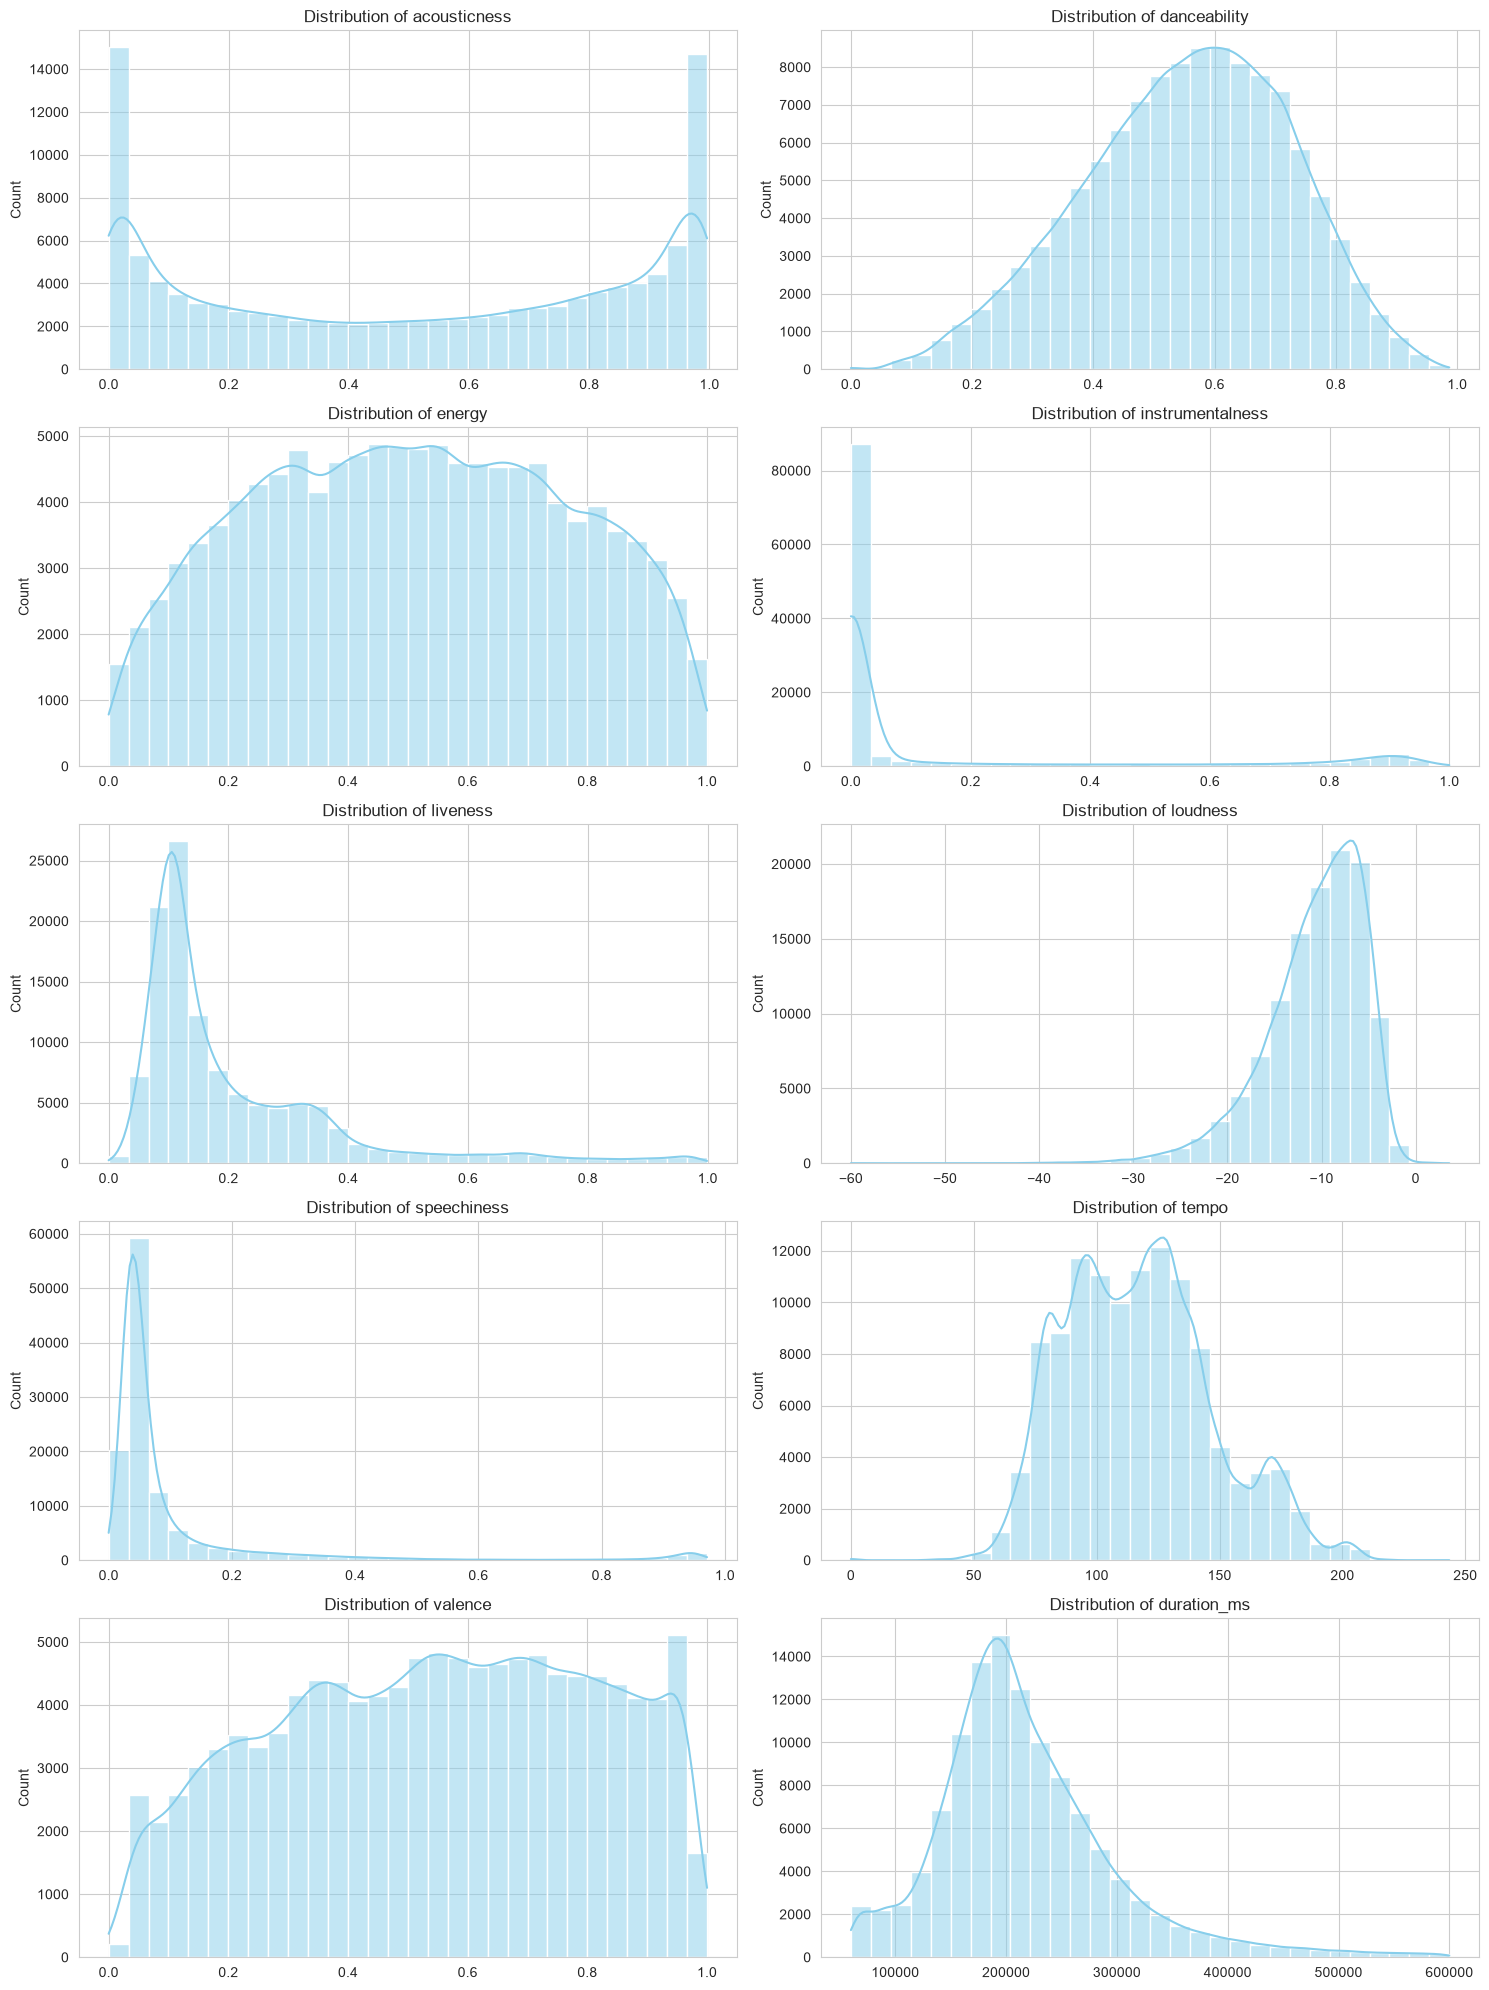

In [8]:
# Select numerical columns (excluding the target and discrete ones like key/mode)
numeric_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
                'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'duration_ms']

# Create a grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(train_pool[col], kde=True, ax=axes[i], color='skyblue', bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#### 5.3 Correlation Matrix

We need to see how features relate to each other and to the target (decade).

- High Positive Correlation (closer to 1): Both variables increase together.

- High Negative Correlation (closer to -1): As one increases, the other decreases.

- Zero correlation: no linear association; nonlinear relationships may remain.

Key thing to check: We want features that correlate with decade (the target), but we don't want features that correlate too strongly with each other (Multicollinearity), as this can confuse some models.

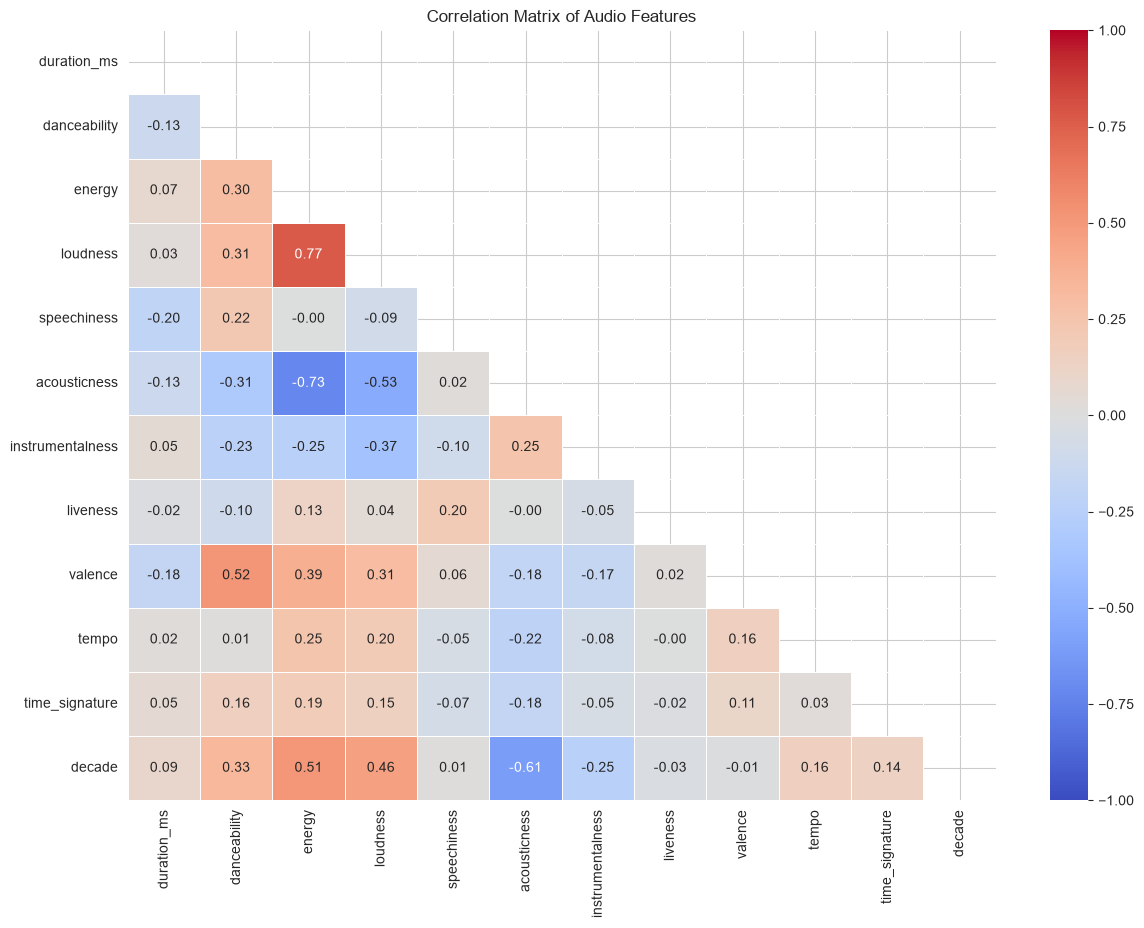

In [9]:
# Calculate correlation matrix
corr_matrix = train_pool.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))

# Create a mask to hide the upper triangle (it's a mirror image)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            annot=True,       
            fmt=".2f",         
            cmap='coolwarm',   
            mask=mask, 
            vmin=-1, vmax=1, 
            center=0,
            linewidths=0.5)

plt.title('Correlation Matrix of Audio Features')
plt.show()

### 6. Fixed Preprocessing Choices

The study includes 1940s–2020s tracks lasting 1–10 minutes. Identifiers, dates, popularity and the explicit-content flag are excluded from predictors. Key and mode are omitted as a fixed design choice; low Pearson correlation alone would not establish low predictive value. Exact feature duplicates are removed, and groups with contradictory decade labels are excluded. Equal class sampling happens before the fixed stratified split.


In [10]:
print(f"Eligibility: 1940s–2020s, duration 1–10 minutes")
print(f"Balanced study: {len(balanced_df):,} tracks; {min_count:,} per decade")
print(f"Training: {len(X_train):,}; test: {len(X_test):,}")


Eligibility: 1940s–2020s, duration 1–10 minutes
Balanced study: 144,324 tracks; 16,036 per decade
Training: 115,459; test: 28,865


#### 6.1 Correlations in the Training Partition

These associations describe the sampled training data. Balancing changes the population being summarized; it does not reveal uniquely “true” relationships.


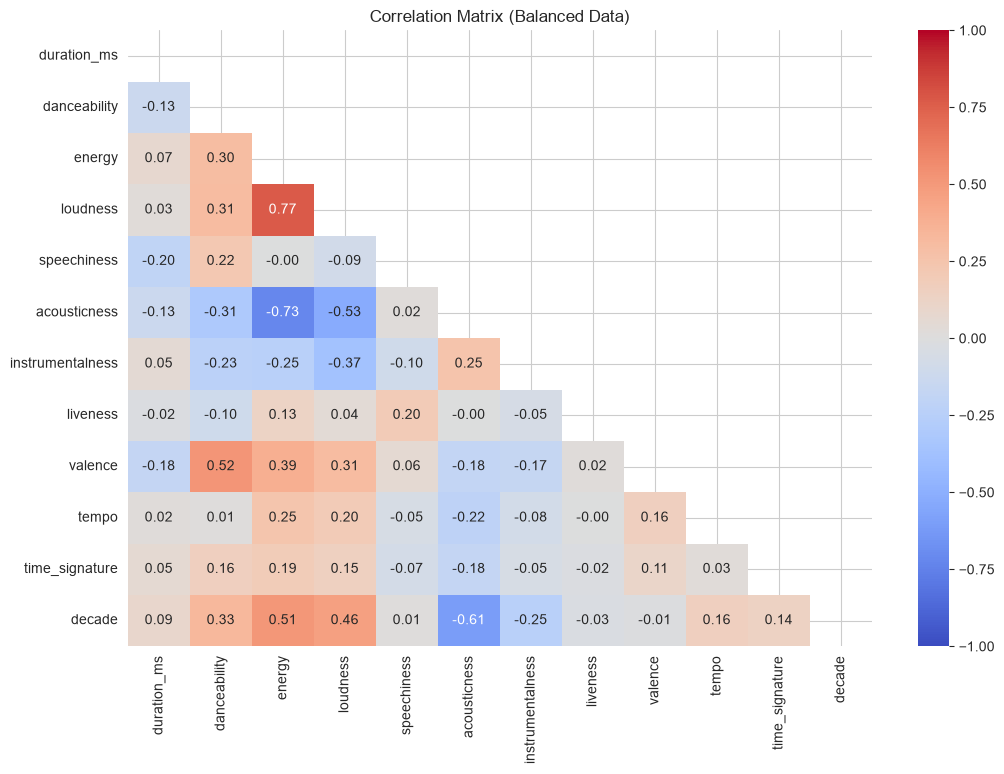

In [11]:
plt.figure(figsize=(12, 8))
corr_matrix_clean = train_pool.corr()

mask = np.triu(np.ones_like(corr_matrix_clean, dtype=bool))
sns.heatmap(corr_matrix_clean, annot=True, fmt=".2f", cmap='coolwarm', 
            mask=mask, vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix (Balanced Data)')
plt.show()

### 7. Random Forest Classifier

The fixed model uses 100 trees and maximum depth 20. It is evaluated once on the reserved test partition; no hyperparameter search is claimed. Correlated predictors may share importance, and impurity importance is not a causal explanation.


In [12]:
# 2. Initialize and Train
# n_estimators=100: We create 100 decision trees.
# max_depth=20: We limit the depth to limit model capacity; this does not guarantee absence of overfitting.
# n_jobs=2: Use two CPU workers.
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=2) 
rf_model.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n--- Model Accuracy ---")
print(f"Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Uniform-random exact baseline: {1/len(rf_model.classes_):.4f}")
print(classification_report(y_test,y_pred,zero_division=0))



--- Model Accuracy ---
Overall Accuracy: 0.3985 (39.85%)
Uniform-random exact baseline: 0.1111
              precision    recall  f1-score   support

        1940       0.58      0.67      0.62      3207
        1950       0.39      0.45      0.41      3207
        1960       0.35      0.42      0.38      3207
        1970       0.32      0.29      0.30      3208
        1980       0.36      0.29      0.32      3207
        1990       0.32      0.24      0.27      3207
        2000       0.33      0.37      0.35      3208
        2010       0.36      0.30      0.33      3207
        2020       0.55      0.55      0.55      3207

    accuracy                           0.40     28865
   macro avg       0.39      0.40      0.39     28865
weighted avg       0.39      0.40      0.39     28865



The output above reports this execution’s held-out accuracy and per-class metrics. The uniform-random exact baseline is the reciprocal of the number of classes. This split does not hold out entire artists or all alternate recordings of the same song.


#### 7.1 Feature Importance Analysis

Which audio characteristics define a decade? The plot below shows which features the model relied on most to make its predictions.

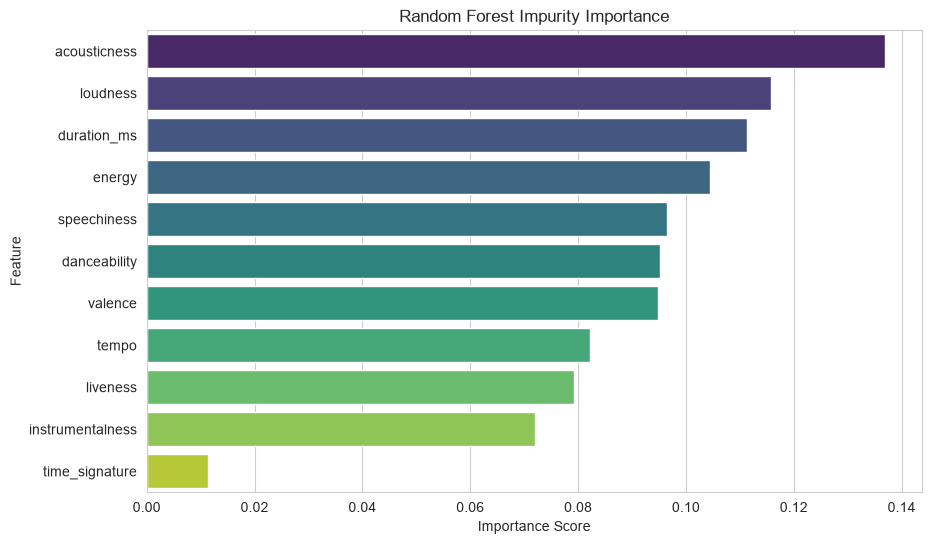

             Feature  Importance
5       acousticness    0.136883
3           loudness    0.115852
0        duration_ms    0.111330
2             energy    0.104551
4        speechiness    0.096491
1       danceability    0.095204
8            valence    0.094858
9              tempo    0.082183
7           liveness    0.079164
6   instrumentalness    0.072098
10    time_signature    0.011387


In [13]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importances, palette='viridis', legend=False)
plt.title('Random Forest Impurity Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print(feature_importances)

The chart ranks mean decrease in Gini impurity within the fitted forest. It can favor continuous variables or distribute importance among correlated predictors; it does not establish technological or cultural causes.


#### 7.2 Confusion Matrix

Accuracy gives us a single number, but the Confusion Matrix tells us the full story. It allows us to visualize:

- Correct Predictions: The diagonal line.

- Neighboring Errors: Predicting 1980s for a 1970s song (common and acceptable).

- Severe Errors: Predicting 1950s for a 2020s song (indicates anomalies).

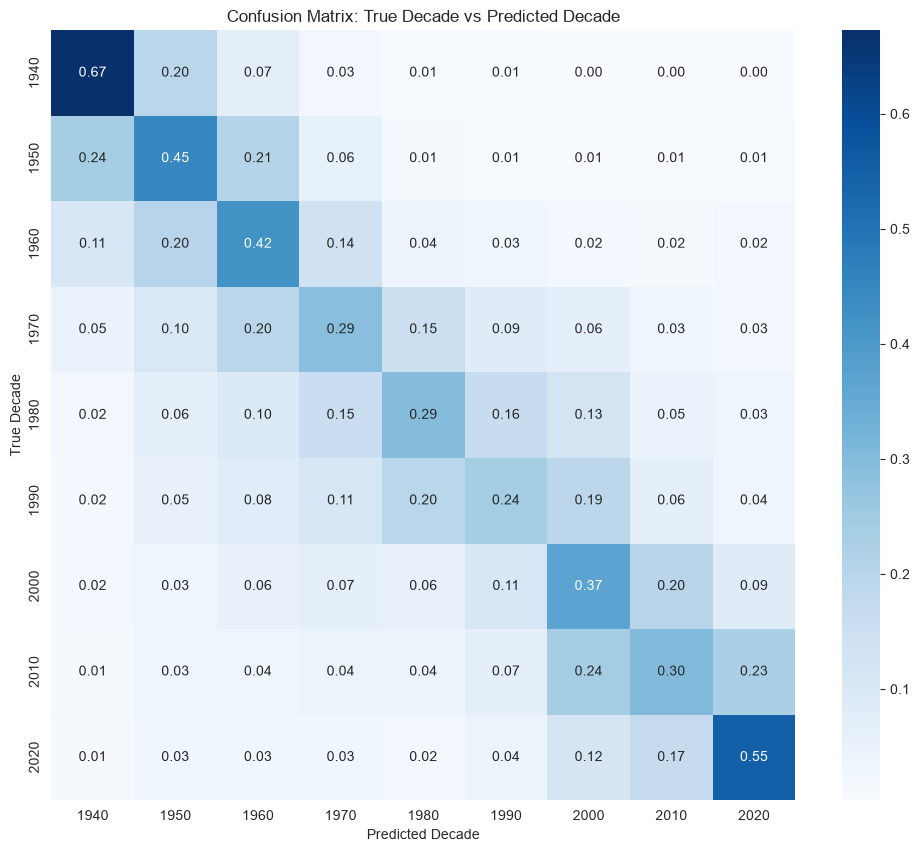

In [14]:
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)

# Normalize the matrix to show percentages instead of raw counts
# This makes it easier to compare decades.
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=sorted(balanced_df['decade'].unique()),
            yticklabels=sorted(balanced_df['decade'].unique()))

plt.title('Confusion Matrix: True Decade vs Predicted Decade')
plt.xlabel('Predicted Decade')
plt.ylabel('True Decade')
plt.show()

Rows in the normalized confusion matrix sum to one and show recall and error destinations for each true decade. Causes of those errors cannot be inferred from this matrix alone.


#### 7.3 Evaluating "Adjacent Accuracy"

While exact accuracy gives us a strict performance metric, it fails to capture the nuance of musical evolution. Cultural changes do not happen overnight; a song released in 1989 is often stylistically identical to one released in 1990, yet a strict classifier considers this a "wrong" prediction.

To better assess the model's utility, we define a new metric: Adjacent Accuracy.

- Definition: A prediction is considered "correct" if it falls within the exact decade OR the immediately neighboring decades (± 10 years).

- Goal: This measures if the model correctly identifies the broader "musical era" (e.g., placing a 70s song in the 60s, 70s, or 80s), effectively filtering out severe errors (like confusing 1950s with 2020s).

In [15]:
def get_adjacent_accuracy(y_true, y_pred):
    truth = np.asarray(y_true)
    prediction = np.asarray(y_pred)
    if truth.ndim != 1 or truth.size == 0 or prediction.shape != truth.shape:
        raise ValueError("Expected equally sized, nonempty one-dimensional arrays")
    if not (np.isfinite(truth).all() and np.isfinite(prediction).all()):
        raise ValueError("Decades must be finite")
    return np.mean(np.abs(truth-prediction) <= 10)

adj_acc = get_adjacent_accuracy(y_test,y_pred)
classes = rf_model.classes_
random_adjacent = np.mean(np.abs(np.asarray(y_test)[:,None]-classes[None,:]) <= 10)
print(f"Exact accuracy: {acc:.2%}; uniform baseline: {1/len(classes):.2%}")
print(f"Adjacent accuracy: {adj_acc:.2%}; uniform baseline: {random_adjacent:.2%}")


Exact accuracy: 39.85%; uniform baseline: 11.11%
Adjacent accuracy: 73.04%; uniform baseline: 30.86%


### 8. Conclusions and Limits

The printed exact and adjacent accuracies are the current results. Adjacent accuracy permits an error of one decade and therefore has its own, substantially higher random baseline. The analysis evaluates a balanced track sample with a fixed split; artists can appear on both sides, related versions may remain, and release metadata can refer to reissues. These results do not establish performance on new artists or identify causes of historical musical change.
